In [82]:
import pandas as pd
import os
SSL_DIR = "soil_dataset_20250703_163248"
dataframe = pd.read_csv(os.path.join("/Users/khalilmisbah/Desktop/CESBIO/AL_Moutmir/Soil_Datasets",SSL_DIR,'doukkala_ssl_datasets/merged_doukkala_smoothed_spectra.csv'))

In [83]:
band_columns = [col for col in dataframe.columns if 'Band_' in col]
band_df = dataframe[band_columns]
band_df.head()

,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,...,Band_225,Band_226,Band_227,Band_228,Band_229,Band_230,Band_231,Band_232,Band_233,Band_234
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.105406,0.106534,0.108895,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.118516,0.120100,0.122743,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111157,0.112858,0.115772,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086597,0.087586,0.089417,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106291,0.108047,0.110867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


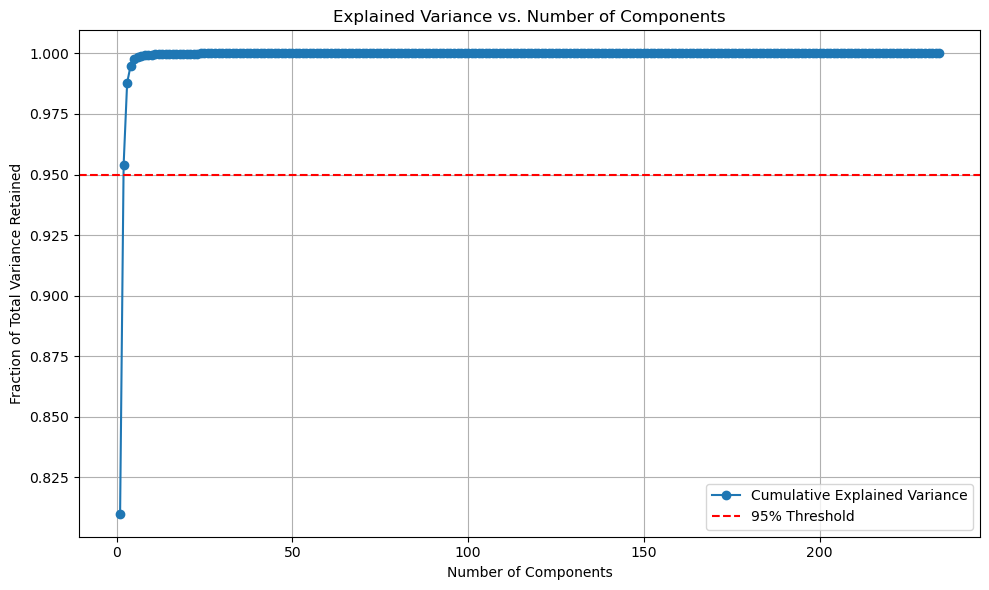

Elbow-based optimal number of components: 3


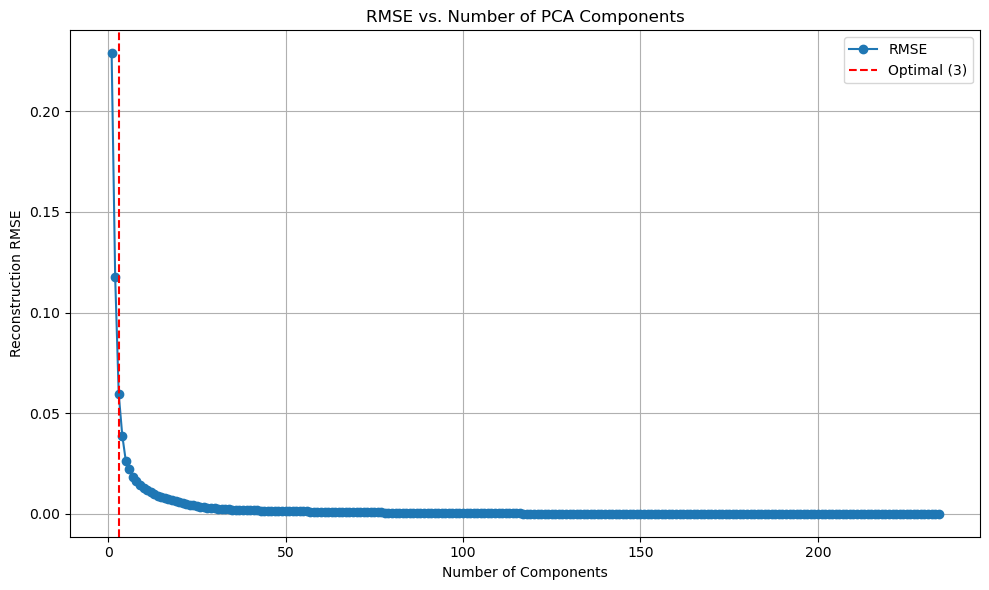

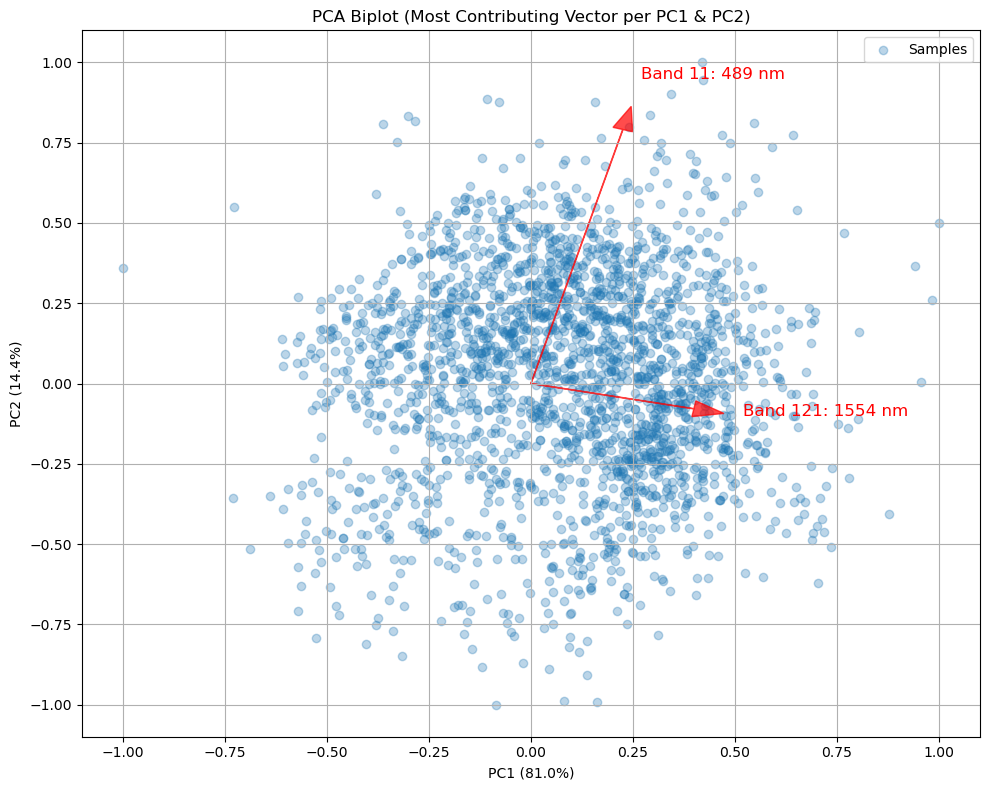

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

# ---------- CONFIGURATION ----------
vector_scale = 5.0  # scale for arrows

# ---------- DATA PREPARATION ----------
# Assume band_df is defined and contains your data

# Load band list CSV
bands_list_path = '/Users/khalilmisbah/Desktop/CESBIO/AL_Moutmir/bandsList.csv'
bands_df = pd.read_csv(bands_list_path)

# Extract wavelengths and add "nm"
wavelengths_nm = bands_df.iloc[:, 1].astype(int).astype(str) + ' nm'

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(band_df.fillna(0))

# ---------- PCA for Analysis ----------
pca_temp = PCA()
pca_temp.fit(X_scaled)
cum_var = np.cumsum(pca_temp.explained_variance_ratio_)

# ---------- Plot Explained Variance Curve ----------
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o', label='Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Fraction of Total Variance Retained')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Find Optimal Number of Components (Elbow) ----------
def find_elbow(cum_var, threshold=0.01):
    diffs = np.diff(cum_var)
    for i in range(1, len(diffs)):
        if diffs[i] < threshold:
            return i + 1
    return len(cum_var)

n_components_opt = find_elbow(cum_var)
print(f'Elbow-based optimal number of components: {n_components_opt}')

# ---------- RMSE vs Number of Components ----------
max_components = X_scaled.shape[1]
rmse_list = []

for n in range(1, max_components + 1):
    pca_iter = PCA(n_components=n)
    X_pca_iter = pca_iter.fit_transform(X_scaled)
    X_reconstructed = pca_iter.inverse_transform(X_pca_iter)
    
    rmse = root_mean_squared_error(X_scaled, X_reconstructed)
    rmse_list.append(rmse)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_components + 1), rmse_list, marker='o', label='RMSE')
plt.axvline(n_components_opt, color='red', linestyle='--', label=f'Optimal ({n_components_opt})')
plt.title('RMSE vs. Number of PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction RMSE')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Apply PCA with Optimal Components ----------
pca = PCA(n_components=n_components_opt)
X_pca = pca.fit_transform(X_scaled)

# ---------- Prepare for Biplot ----------
principal_components_2d = X_pca[:, :2]
loadings_2d = pca.components_[:2, :].T  # shape (n_features, 2)

def minmax_scale_to_unit_interval(data):
    scaled = np.empty_like(data)
    for i in range(data.shape[1]):
        col = data[:, i]
        min_val, max_val = np.min(col), np.max(col)
        if max_val == min_val:
            scaled[:, i] = 0
        else:
            scaled[:, i] = 2 * (col - min_val) / (max_val - min_val) - 1
    return scaled

principal_components_norm = minmax_scale_to_unit_interval(principal_components_2d)
loadings_scaled = loadings_2d * vector_scale

# ---------- Select Most Contributing Vectors ----------
top_pc1_index = np.argmax(np.abs(loadings_2d[:, 0]))
top_pc2_index = np.argmax(np.abs(loadings_2d[:, 1]))
top_indices = np.unique([top_pc1_index, top_pc2_index])

# ---------- PCA Biplot ----------
plt.figure(figsize=(10, 8))
plt.scatter(principal_components_norm[:, 0], principal_components_norm[:, 1], alpha=0.3, label='Samples')

for i in top_indices:
    x, y = loadings_scaled[i]
    label = f'Band {i+1}: {wavelengths_nm[i]}' if i < len(wavelengths_nm) else f'Feature {i}'
    plt.arrow(0, 0, x, y, color='r', alpha=0.7, head_width=0.05, length_includes_head=True)
    plt.text(x * 1.1, y * 1.1, label, color='r', fontsize=12)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Biplot (Most Contributing Vector per PC1 & PC2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




In [85]:
# ---------- TOP 10 CONTRIBUTORS TO PC1 AND PC2 ----------
top_10_pc1_indices = np.argsort(np.abs(loadings_2d[:, 0]))[::-1][:10]
top_10_pc2_indices = np.argsort(np.abs(loadings_2d[:, 1]))[::-1][:10]

print("Top 10 contributors to PC1:")
for idx in top_10_pc1_indices:
    label = f'Band {idx+1}: {wavelengths_nm[idx]}' if idx < len(wavelengths_nm) else f'Feature {idx}'
    print(f'{label} | Loading: {loadings_2d[idx, 0]:.4f}')

print("\nTop 10 contributors to PC2:")
for idx in top_10_pc2_indices:
    label = f'Band {idx+1}: {wavelengths_nm[idx]}' if idx < len(wavelengths_nm) else f'Feature {idx}'
    print(f'{label} | Loading: {loadings_2d[idx, 1]:.4f}')



Top 10 contributors to PC1:
Band 121: 1554 nm | Loading: 0.0945
Band 122: 1565 nm | Loading: 0.0944
Band 99: 1317 nm | Loading: 0.0943
Band 126: 1606 nm | Loading: 0.0942
Band 127: 1616 nm | Loading: 0.0942
Band 123: 1575 nm | Loading: 0.0942
Band 128: 1627 nm | Loading: 0.0941
Band 129: 1637 nm | Loading: 0.0941
Band 130: 1647 nm | Loading: 0.0941
Band 131: 1656 nm | Loading: 0.0940

Top 10 contributors to PC2:
Band 11: 489 nm | Loading: 0.1726
Band 10: 482 nm | Loading: 0.1724
Band 9: 475 nm | Loading: 0.1722
Band 12: 497 nm | Loading: 0.1719
Band 8: 468 nm | Loading: 0.1717
Band 13: 504 nm | Loading: 0.1708
Band 14: 512 nm | Loading: 0.1698
Band 15: 519 nm | Loading: 0.1681
Band 16: 527 nm | Loading: 0.1658
Band 17: 535 nm | Loading: 0.1641


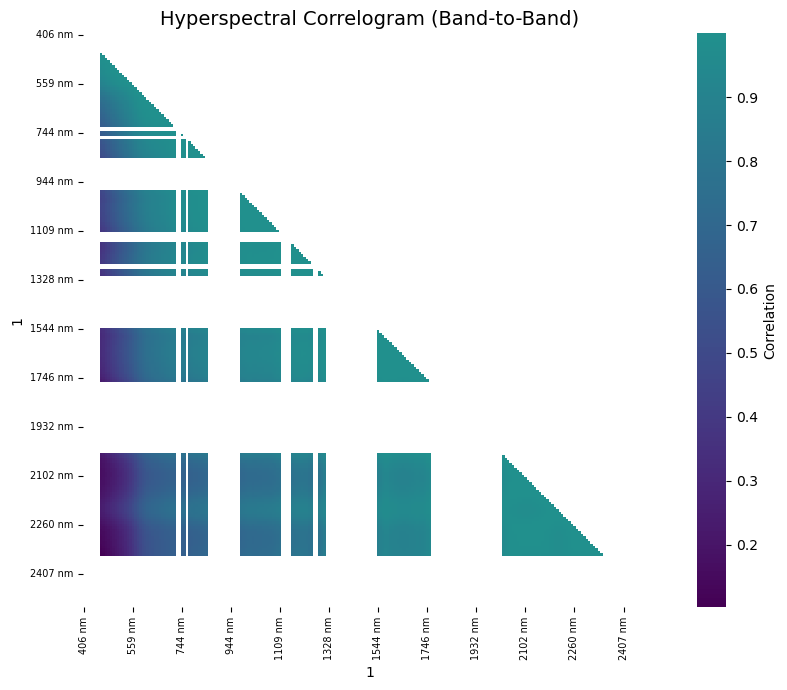

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- LOAD WAVELENGTH LABELS ----------
bands_df = pd.read_csv('/Users/khalilmisbah/Desktop/CESBIO/AL_Moutmir/bandsList.csv', header=None)
band_labels = bands_df.iloc[:, 1].astype(int).astype(str) + ' nm'

# ---------- CORRELATION MATRIX ----------
band_df_clean = band_df.fillna(0)
corr_matrix = band_df_clean.corr()

# ---------- APPLY WAVELENGTH LABELS ----------
corr_matrix.columns = band_labels
corr_matrix.index = band_labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# ---------- PLOTTING ----------
plt.figure(figsize=(9, 7))  # Smaller figure size
sns.heatmap(
    corr_matrix,
    mask = mask,
    cmap='viridis',       # Continuous diverging colormap
    center=1.0,            # Emphasize diagonal self-correlation
    square=True,
    cbar_kws={'label': 'Correlation'},
    xticklabels=20,        # Reduce label density
    yticklabels=20,
    linewidths=0.0         # Remove grid lines for continuous color
)

plt.title('Hyperspectral Correlogram (Band-to-Band)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()



In [128]:
# Find duplicate rows based on 'Latitude_Y' and 'Longitude_X'
df_clean = dataframe.dropna(axis=1, how='all')

# Row count before removing duplicates
print(f"Rows before removing duplicates: {len(df_clean)}")

# Remove duplicates
duplicates = df_clean.drop_duplicates(subset=['Latitude_Y', 'Longitude_X'])

# Row count after removing duplicates
print(f"Rows after removing duplicates: {len(duplicates)}")

# Optionally, print the duplicate-free DataFrame
print(duplicates)

Rows before removing duplicates: 2276
Rows after removing duplicates: 2276
      Longitude_X  Latitude_Y  Sand%  Clay%  Total_Silt%  Fine silt%  \
0         -8.5045     32.5532   85.0    4.0         11.0         7.0   
1         -8.3182     32.7204   87.0    1.0         12.0         6.0   
2         -8.3186     32.7201   87.0    4.0          9.0         5.0   
3         -8.3359     32.6863   66.0   17.0         17.0        11.0   
4         -8.3445     32.7117   35.0   25.0         40.0        24.0   
...           ...         ...    ...    ...          ...         ...   
2271      -8.3199     32.7213   92.0    1.0          7.0         2.0   
2272      -8.4928     32.8381   82.0    8.0         10.0        10.0   
2273      -8.5384     32.7939   43.0   31.0         26.0        26.0   
2274      -8.5403     32.7835   26.0   38.0         36.0        36.0   
2275      -8.5319     32.8013   81.0    8.0         11.0        11.0   

      Coarse silt%  Coarse element %  pH_water  CaCo3%_Total

In [ ]:
from sklearn.cluster import KMeans

# Drop columns with all NaN values
df_clean = dataframe.dropna(axis=1, how='all').copy()
n_clusters = len(df_clean)

# KMeans clustering based on latitude and longitude
coords = df_clean[['Latitude_Y', 'Longitude_X']]
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(coords)

# Set X as all columns starting with 'Band_' plus 'cluster'
band_cols = [col for col in df_clean.columns if col.startswith('Band_')]
X = df_clean[band_cols + ['cluster']]

# Find a y column before Band_ columns, excluding latitude and longitude and cluster
pre_band_cols = [col for col in df_clean.columns if not col.startswith('Band_')]
pre_band_cols = [col for col in pre_band_cols if col not in ['Latitude_Y', 'Longitude_X', 'cluster']]
if pre_band_cols:
    y_col = pre_band_cols[-1]  # Choose the last one before Band_ columns
    y = df_clean[y_col]
else:
    y = None

print(X.head())

     Band_8    Band_9   Band_10   Band_11   Band_12   Band_13   Band_14  \
0  0.105406  0.106534  0.108895  0.111978  0.114891  0.117885  0.121605   
1  0.118516  0.120100  0.122743  0.126194  0.129660  0.133277  0.137385   
2  0.111157  0.112858  0.115772  0.119150  0.122670  0.126309  0.130010   
3  0.086597  0.087586  0.089417  0.091562  0.093628  0.095790  0.098420   
4  0.106291  0.108047  0.110867  0.114236  0.118031  0.121650  0.125557   

    Band_15   Band_16   Band_17  ...  Band_205  Band_206  Band_207  Band_208  \
0  0.125832  0.131051  0.135668  ...  0.282812  0.273486  0.265979  0.260454   
1  0.141953  0.147749  0.153690  ...  0.355960  0.343560  0.334725  0.328537   
2  0.134341  0.139575  0.145107  ...  0.364910  0.353724  0.345528  0.340316   
3  0.101123  0.104901  0.108832  ...  0.377346  0.365292  0.357226  0.350806   
4  0.129874  0.134815  0.140256  ...  0.369431  0.357344  0.348007  0.341111   

   Band_209  Band_210  Band_211  Band_212  Band_213  cluster  
0  0.

In [99]:
X = X.sort_values(by='cluster', ascending=False)

In [100]:
X

,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Band_16,Band_17,...,Band_205,Band_206,Band_207,Band_208,Band_209,Band_210,Band_211,Band_212,Band_213,cluster
351,0.109573,0.110839,0.113021,0.115825,0.118518,0.121194,0.124556,0.128316,0.133355,0.138317,...,0.309813,0.299885,0.293028,0.288735,0.282253,0.275779,0.269498,0.263719,0.260140,2275
133,0.109152,0.110103,0.112163,0.114651,0.116883,0.118888,0.121648,0.124458,0.128200,0.131974,...,0.234018,0.225270,0.218779,0.213493,0.206573,0.199848,0.194035,0.189258,0.186453,2274
1621,0.111793,0.112008,0.113197,0.115170,0.117017,0.119096,0.122177,0.125293,0.129131,0.133579,...,0.286172,0.275176,0.267394,0.262045,0.254561,0.246922,0.239544,0.233042,0.229079,2273
1518,0.109222,0.111078,0.114224,0.117764,0.120506,0.123111,0.125794,0.129043,0.133779,0.138367,...,0.291064,0.282095,0.275721,0.271442,0.265239,0.256788,0.250521,0.245430,0.244219,2272
1524,0.110477,0.112430,0.115803,0.119143,0.122621,0.125943,0.129326,0.133259,0.138244,0.142755,...,0.312163,0.302922,0.296277,0.291037,0.283324,0.275597,0.268375,0.261740,0.257576,2271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,0.067909,0.068086,0.068947,0.070116,0.071365,0.072704,0.074737,0.076893,0.079734,0.082870,...,0.223177,0.215991,0.211152,0.207227,0.201747,0.195882,0.190038,0.184816,0.181887,4
1487,0.121281,0.122641,0.125146,0.128494,0.131514,0.134726,0.138540,0.142413,0.147358,0.152264,...,0.250574,0.242033,0.235929,0.231015,0.223948,0.217203,0.210764,0.205038,0.201769,3
1294,0.101903,0.103463,0.105831,0.108889,0.112195,0.115257,0.118499,0.122007,0.126126,0.130048,...,0.278377,0.268868,0.262332,0.260217,0.254901,0.249862,0.245146,0.240454,0.235923,2
1862,0.104043,0.105109,0.106997,0.109426,0.112081,0.114788,0.118217,0.122080,0.127040,0.131984,...,0.337678,0.325869,0.317534,0.313489,0.306427,0.300776,0.296257,0.292076,0.289682,1


In [127]:
from sklearn.model_selection import ShuffleSplit, GroupShuffleSplit

X = X.copy()
# --- Split 1: ShuffleSplit (sample-level shuffle) ---
ss = ShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx_ss, test_idx_ss = next(ss.split(X, y))

X['split_ss'] = 'test'
X.loc[train_idx_ss, 'split_ss'] = 'train'

# --- Split 2: GroupShuffleSplit (group-level shuffle) ---
groups = X['cluster'].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx_gss, test_idx_gss = next(gss.split(X, y, groups=X.index))

X['split_gss'] = 'test'
X.loc[train_idx_gss, 'split_gss'] = 'train'

# --- Visual Comparison ---
print("\n=== Comparison of ShuffleSplit vs GroupShuffleSplit ===\n")
print(X[['cluster', 'split_ss', 'split_gss']])

# --- Count Matching ---
matches = (X['split_ss'] == X['split_gss']).sum()
print(f"\nTotal matching splits: {matches} / {len(X)}")


=== Comparison of ShuffleSplit vs GroupShuffleSplit ===

      cluster split_ss split_gss
0        1321    train     train
1        1697    train     train
2        2211    train     train
3         403    train     train
4        1924    train     train
...       ...      ...       ...
2271      135    train     train
2272      367    train     train
2273     1661    train     train
2274     1039    train     train
2275     1004    train     train

[2276 rows x 3 columns]

Total matching splits: 2276 / 2276
